# EDA - Medical Text Classification Dataset

Dataset com **dois campos**:
- `condition_label`: target de **1 a 5** representando a categoria/gravidade da condição médica
- `medical_abstract`: texto do diagnóstico/resumo médico

**Objetivos:**
1. Entender distribuição e balanceamento das 5 classes
2. Analisar características dos textos por classe (tamanho, vocabulário)
3. Identificar termos discriminativos por label via TF-IDF
4. Detectar problemas: nulos, duplicados, desbalanceamento

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
colors = sns.color_palette('Set2', 5)

DATA_PATH = '../data/medical_tc_train.csv'
LABEL_NAMES = {
    1: 'Neoplasias',
    2: 'Digestivo/Infeccioso',
    3: 'Neurológico/Musculoesq.',
    4: 'Cardiovascular',
    5: 'Outros/Sistêmico'
}

print("✓ Imports carregados")

✓ Imports carregados


## 2. Carregamento e Inspeção Inicial

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(f"\nTipos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nTextos duplicados: {df['medical_abstract'].duplicated().sum()}")
print(f"Labels únicos: {sorted(df['condition_label'].unique())}")
df.head(3)

Shape: (11550, 2)
Colunas: ['condition_label', 'medical_abstract']

Tipos:
condition_label      int64
medical_abstract    object
dtype: object

Valores nulos:
condition_label     0
medical_abstract    0
dtype: int64

Textos duplicados: 2105
Labels únicos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."


## 3. Distribuição de Classes (Balanceamento)

Distribuição de labels:
                 Count  Percentual (%)
condition_label                       
1                 2530           21.90
2                 1195           10.35
3                 1540           13.33
4                 2441           21.13
5                 3844           33.28


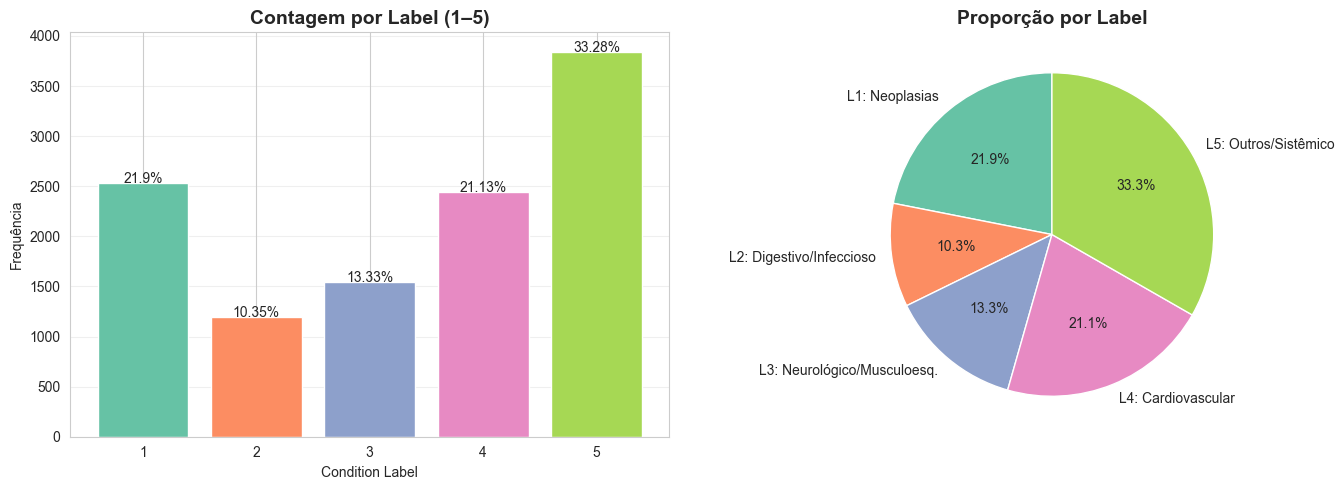


Ratio máximo/mínimo entre classes: 3.22x
⚠️  Dataset DESBALANCEADO — considerar class_weight='balanced' ou oversampling
✓ Salvo: reports/figures/01_label_distribution.png


In [3]:
label_counts = df['condition_label'].value_counts().sort_index()
label_pct = (label_counts / len(df) * 100).round(2)

print("Distribuição de labels:")
print(pd.DataFrame({'Count': label_counts, 'Percentual (%)': label_pct}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title('Contagem por Label (1–5)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Condition Label')
axes[0].set_ylabel('Frequência')
for bar, pct in zip(bars, label_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{pct}%', ha='center', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(label_counts.values,
            labels=[f'L{i}: {LABEL_NAMES[i]}' for i in label_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporção por Label', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

max_ratio = label_counts.max() / label_counts.min()
print(f"\nRatio máximo/mínimo entre classes: {max_ratio:.2f}x")
if max_ratio > 2:
    print("⚠️  Dataset DESBALANCEADO — considerar class_weight='balanced' ou oversampling")
else:
    print("✓ Dataset relativamente BALANCEADO")
print("✓ Salvo: reports/figures/01_label_distribution.png")

## 4. Análise Estatística dos Textos

In [4]:
df['char_count'] = df['medical_abstract'].str.len()
df['word_count'] = df['medical_abstract'].str.split().str.len()
df['sentence_count'] = df['medical_abstract'].str.count(r'[.!?]+')
df['avg_word_length'] = df['medical_abstract'].apply(
    lambda x: round(np.mean([len(w) for w in str(x).split()]), 2) if pd.notna(x) else 0
)

stats_cols = ['char_count', 'word_count', 'sentence_count', 'avg_word_length']
print("=== Estatísticas globais dos textos ===")
print(df[stats_cols].describe().round(2))

print("\n=== Média por Label ===")
print(df.groupby('condition_label')[stats_cols].mean().round(2))

=== Estatísticas globais dos textos ===
       char_count  word_count  sentence_count  avg_word_length
count    11550.00    11550.00        11550.00         11550.00
mean      1229.10      179.64           10.71             5.91
std        505.96       76.37            6.04             0.46
min        170.00       24.00            2.00             4.50
25%        847.00      122.00            7.00             5.59
50%       1208.00      175.00            9.00             5.88
75%       1587.00      234.00           13.00             6.18
max       3999.00      596.00           54.00             8.33

=== Média por Label ===
                 char_count  word_count  sentence_count  avg_word_length
condition_label                                                         
1                   1187.77      174.17           10.03             5.87
2                   1225.30      178.66           10.86             5.91
3                   1124.21      163.34            9.35             5.94
4  

## 5. Distribuição de Comprimento por Label

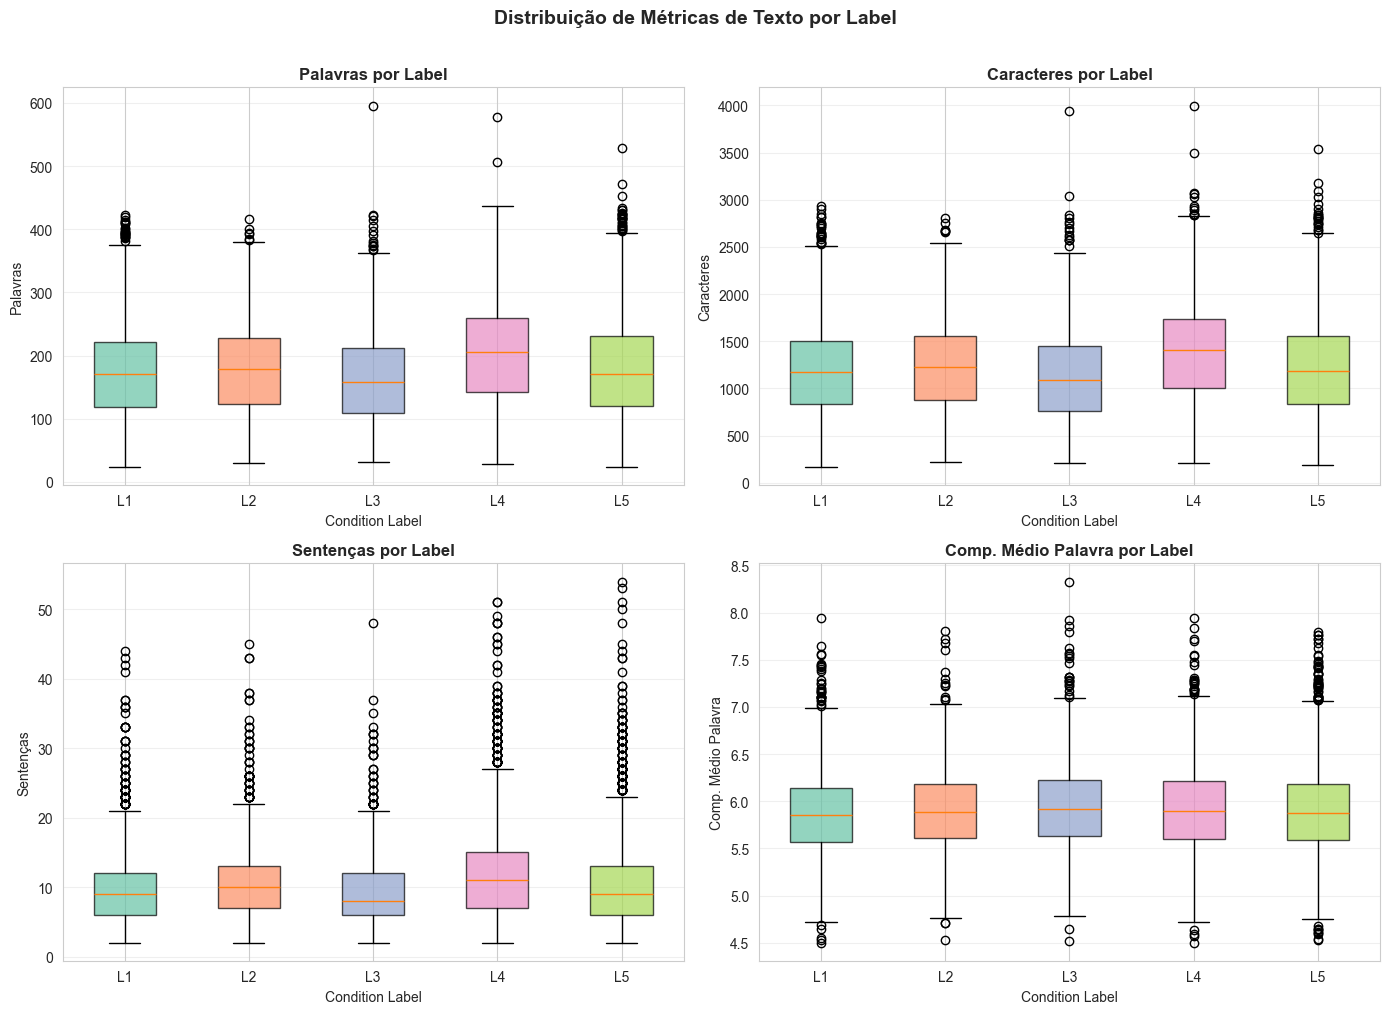

✓ Salvo: reports/figures/02_text_stats_by_label.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [('word_count', 'Palavras'), ('char_count', 'Caracteres'),
           ('sentence_count', 'Sentenças'), ('avg_word_length', 'Comp. Médio Palavra')]

for ax, (col, label) in zip(axes.flatten(), metrics):
    data = [df[df['condition_label'] == lbl][col].values
            for lbl in sorted(df['condition_label'].unique())]
    bp = ax.boxplot(data, labels=[f'L{i}' for i in sorted(df['condition_label'].unique())],
                    patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{label} por Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Condition Label')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuição de Métricas de Texto por Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/02_text_stats_by_label.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Salvo: reports/figures/02_text_stats_by_label.png")

## 6. Palavras Mais Frequentes por Label

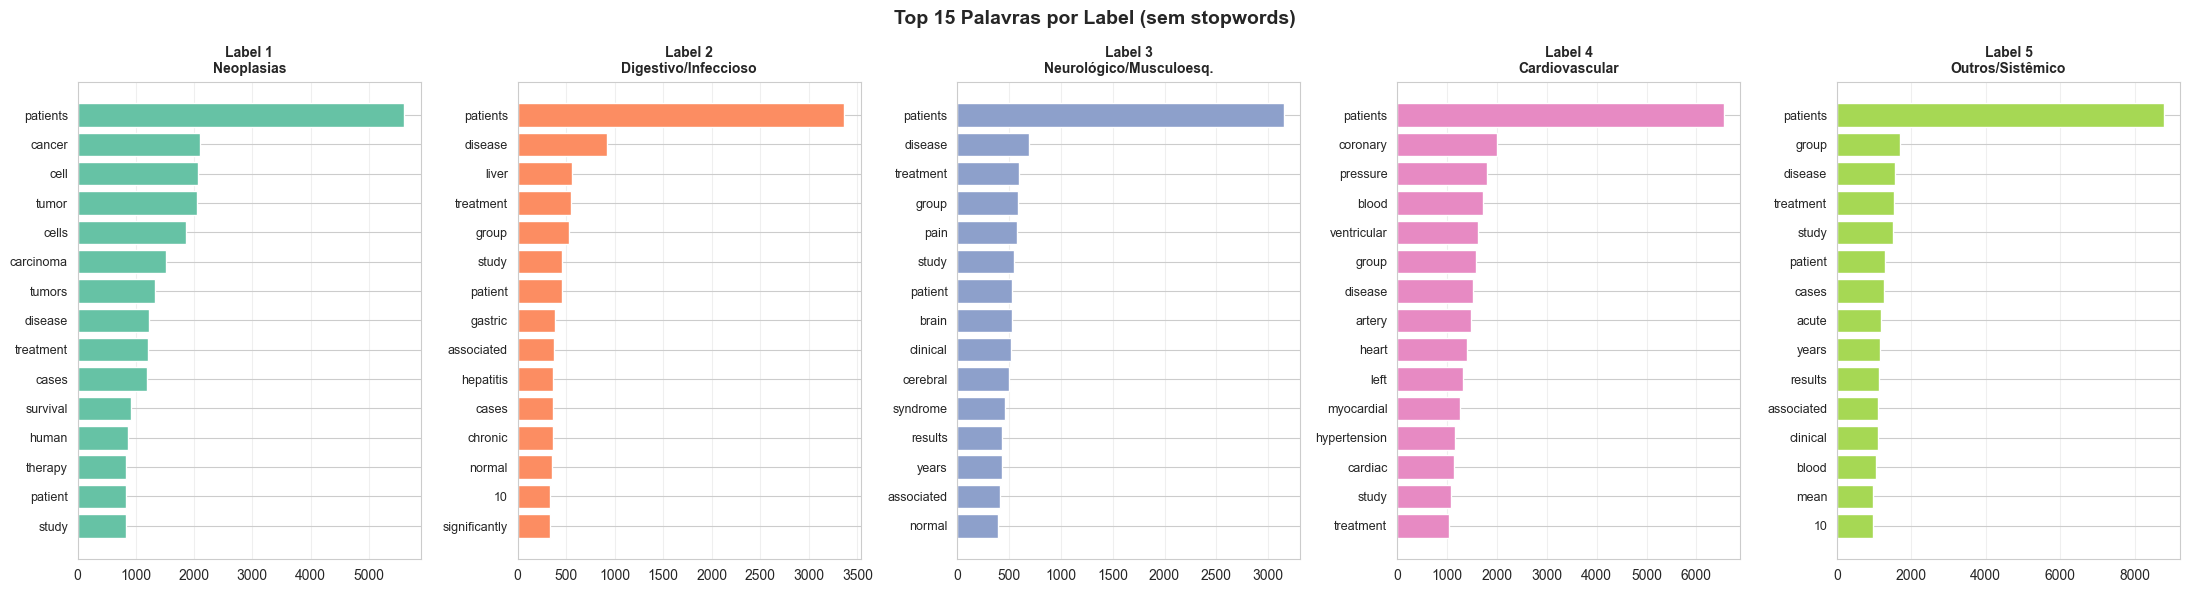

✓ Salvo: reports/figures/03_top_words_per_label.png


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Top 15 Palavras por Label (sem stopwords)', fontsize=14, fontweight='bold')

for i, label in enumerate(sorted(df['condition_label'].unique())):
    texts = df[df['condition_label'] == label]['medical_abstract'].tolist()
    vec = CountVectorizer(stop_words='english', max_features=15)
    matrix = vec.fit_transform(texts)
    word_freq = dict(zip(vec.get_feature_names_out(), matrix.toarray().sum(axis=0)))
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:15]
    words, freqs = zip(*top_words)

    axes[i].barh(range(len(words)), freqs, color=colors[i])
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words, fontsize=9)
    axes[i].set_title(f'Label {label}\n{LABEL_NAMES[label]}', fontsize=10, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/03_top_words_per_label.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Salvo: reports/figures/03_top_words_per_label.png")

## 7. Termos Discriminativos (TF-IDF por Classe)

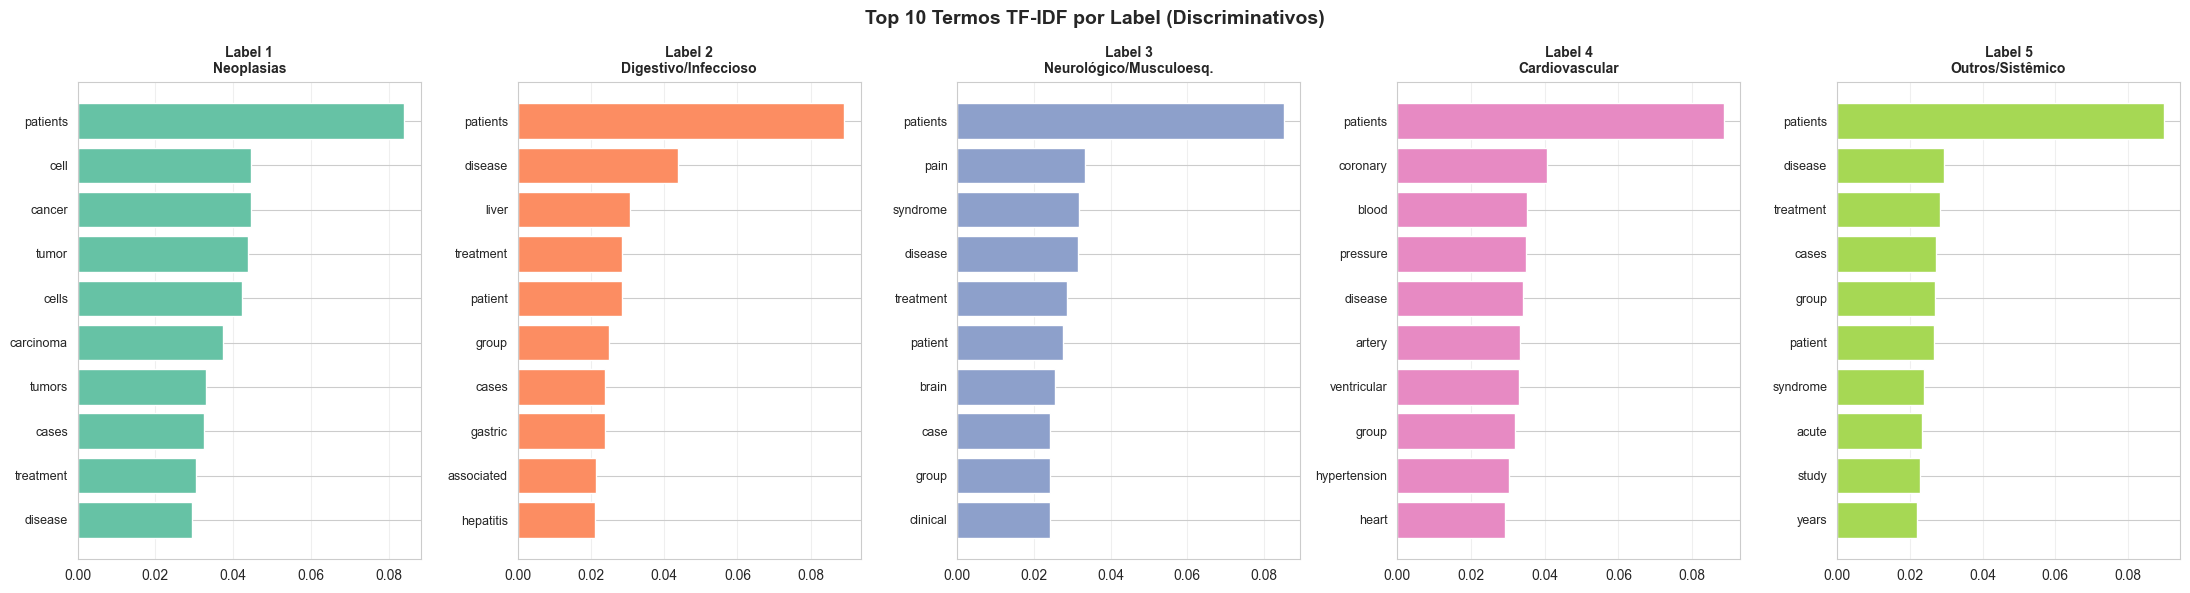

✓ Salvo: reports/figures/04_tfidf_per_label.png


In [7]:
# TF-IDF médio por classe — mostra termos mais CARACTERÍSTICOS de cada label
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Top 10 Termos TF-IDF por Label (Discriminativos)', fontsize=14, fontweight='bold')

for i, label in enumerate(sorted(df['condition_label'].unique())):
    texts = df[df['condition_label'] == label]['medical_abstract'].tolist()
    vec = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1, 1))
    tfidf_matrix = vec.fit_transform(texts)
    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-10:][::-1]
    top_terms = [(vec.get_feature_names_out()[j], mean_tfidf[j]) for j in top_idx]
    words, scores = zip(*top_terms)

    axes[i].barh(range(len(words)), scores, color=colors[i])
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words, fontsize=9)
    axes[i].set_title(f'Label {label}\n{LABEL_NAMES[label]}', fontsize=10, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/04_tfidf_per_label.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Salvo: reports/figures/04_tfidf_per_label.png")

## 8. Diversidade de Vocabulário (TTR)

=== Diversidade de Vocabulário por Label ===
 Label               Categoria  Amostras  Total palavras  Vocabulário único    TTR
     1              Neoplasias      2530          440660              36669 0.0832
     2    Digestivo/Infeccioso      1195          213502              22518 0.1055
     3 Neurológico/Musculoesq.      1540          251541              26748 0.1063
     4          Cardiovascular      2441          488529              35006 0.0717
     5        Outros/Sistêmico      3844          680617              51398 0.0755


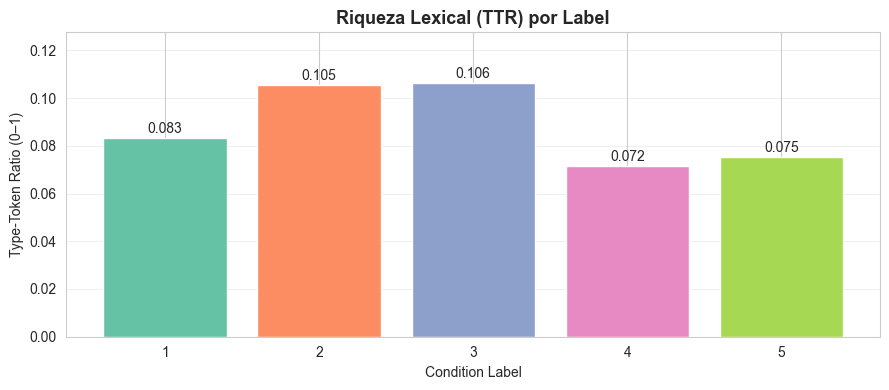

✓ Salvo: reports/figures/05_lexical_richness.png


In [8]:
# Type-Token Ratio (TTR) = vocab único / total de palavras — mede riqueza lexical
vocab_stats = []
for label in sorted(df['condition_label'].unique()):
    texts = df[df['condition_label'] == label]['medical_abstract'].tolist()
    all_words = ' '.join(texts).lower().split()
    unique_words = set(all_words)
    vocab_stats.append({
        'Label': label,
        'Categoria': LABEL_NAMES[label],
        'Amostras': len(texts),
        'Total palavras': len(all_words),
        'Vocabulário único': len(unique_words),
        'TTR': round(len(unique_words) / len(all_words), 4)
    })

vocab_df = pd.DataFrame(vocab_stats)
print("=== Diversidade de Vocabulário por Label ===")
print(vocab_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(vocab_df['Label'], vocab_df['TTR'], color=colors)
ax.set_title('Riqueza Lexical (TTR) por Label', fontsize=13, fontweight='bold')
ax.set_xlabel('Condition Label')
ax.set_ylabel('Type-Token Ratio (0–1)')
ax.set_ylim(0, max(vocab_df['TTR']) * 1.2)
for i, (lbl, ttr) in enumerate(zip(vocab_df['Label'], vocab_df['TTR'])):
    ax.text(lbl, ttr + 0.002, f'{ttr:.3f}', ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/05_lexical_richness.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Salvo: reports/figures/05_lexical_richness.png")

## 9. Exemplos de Abstract por Label

In [9]:
for label in sorted(df['condition_label'].unique()):
    sample = df[df['condition_label'] == label].iloc[0]
    text = sample['medical_abstract']
    print(f"\n{'='*80}")
    print(f"LABEL {label} — {LABEL_NAMES[label]}")
    print(f"{len(text)} chars | {len(text.split())} palavras")
    print(f"{'='*80}")
    print(text[:400] + "..." if len(text) > 400 else text)


LABEL 1 — Neoplasias
1207 chars | 187 palavras
Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase (NSE) is the isoform of enolase, a glycolytic enzyme found in the neuroendocrine system. Neuropeptide Y (NPY) is a peptide recently discovered in the peripheral and central nervous systems. Serum NSE and plasma NPY levels have been reported to be increased in some patients with pheo...

LABEL 2 — Digestivo/Infeccioso
1771 chars | 256 palavras
Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both the prevalence and types of sexually transmitted diseases has occurred. Up to 55 percent of homosexual men with anorectal complaints have gonorrhea; 80 percent of the patients with syphilis are homosexuals. Chlamydia is found in 15 percent of asympto...

LABEL 3 — Neurológico/Musculoesq.
1489 chars | 233 palavras
Does carotid restenosis p

## 10. Resumo e Insights para Modelagem

### Características do Dataset
- **Tipo**: Classificação multiclasse de texto médico (5 classes)
- **Target**: `condition_label` (1–5) — categoria/gravidade da condição

### Pontos de Atenção para o Modelo
1. **Balanceamento**: Se desbalanceado → usar `class_weight='balanced'` na Logistic Regression
2. **Comprimento dos textos**: Abstracts longos → TF-IDF com `max_features` adequado; modelos BERT truncam em 512 tokens
3. **Vocabulário médico especializado**: Stop words do sklearn removem termos comuns; termos técnicos são os mais discriminativos
4. **Bigramas**: Expressões como `coronary artery`, `lymph node` mais informativas que unigramas → `ngram_range=(1,2)`
5. **TTR**: Labels com TTR alto têm vocabulário mais diverso → podem ser mais difíceis de classificar

### Próximos Passos
- ✅ EDA concluída — artefatos salvos em `reports/figures/`
- ▶ Implementar baseline TF-IDF + Logistic Regression (`02_model_baseline.ipynb`)
- ▶ Extrair pré-processamento para `src/triage_ml/data/`